In [16]:
import pandas as pd

In [17]:
import numpy as np


In [18]:
df=pd.read_csv("Global YouTube Statistics.csv", encoding='latin1')

In [21]:
df.head()

,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,subscribers_for_last_30_days,created_year,created_month,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
0,1,T-Series,245000000,2.280000e+11,Music,T-Series,20082,India,IN,Music,...,2000000.0,2006.0,Mar,13.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880
1,2,YouTube Movies,170000000,0.000000e+00,Film & Animation,youtubemovies,1,United States,US,Games,...,NaN,2006.0,Mar,5.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
2,3,MrBeast,166000000,2.836884e+10,Entertainment,MrBeast,741,United States,US,Entertainment,...,8000000.0,2012.0,Feb,20.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
3,4,Cocomelon - Nursery Rhymes,162000000,1.640000e+11,Education,Cocomelon - Nursery Rhymes,966,United States,US,Education,...,1000000.0,2006.0,Sep,1.0,88.2,3.282395e+08,14.70,270663028.0,37.090240,-95.712891
4,5,SET India,159000000,1.480000e+11,Shows,SET India,116536,India,IN,Entertainment,...,1000000.0,2006.0,Sep,20.0,28.1,1.366418e+09,5.36,471031528.0,20.593684,78.962880


In [5]:
df.shape

(995, 28)

In [6]:
df.columns

Index(['rank', 'Youtuber', 'subscribers', 'video views', 'category', 'Title',
       'uploads', 'Country', 'Abbreviation', 'channel_type',
       'video_views_rank', 'country_rank', 'channel_type_rank',
       'video_views_for_the_last_30_days', 'lowest_monthly_earnings',
       'highest_monthly_earnings', 'lowest_yearly_earnings',
       'highest_yearly_earnings', 'subscribers_for_last_30_days',
       'created_year', 'created_month', 'created_date',
       'Gross tertiary education enrollment (%)', 'Population',
       'Unemployment rate', 'Urban_population', 'Latitude', 'Longitude'],
      dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 995 entries, 0 to 994
Data columns (total 28 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   rank                                     995 non-null    int64  
 1   Youtuber                                 995 non-null    str    
 2   subscribers                              995 non-null    int64  
 3   video views                              995 non-null    float64
 4   category                                 949 non-null    str    
 5   Title                                    995 non-null    str    
 6   uploads                                  995 non-null    int64  
 7   Country                                  873 non-null    str    
 8   Abbreviation                             873 non-null    str    
 9   channel_type                             965 non-null    str    
 10  video_views_rank                         994 non-null    floa

# Data Cleaning
The purpose of this step is to identify and handle missing values, duplicate records, incorrect data types, and inconsistencies in the dataset before performing analysis.


In [10]:
df.isnull().sum()

rank                                         0
Youtuber                                     0
subscribers                                  0
video views                                  0
category                                    46
Title                                        0
uploads                                      0
Country                                    122
Abbreviation                               122
channel_type                                30
video_views_rank                             1
country_rank                               116
channel_type_rank                           33
video_views_for_the_last_30_days            56
lowest_monthly_earnings                      0
highest_monthly_earnings                     0
lowest_yearly_earnings                       0
highest_yearly_earnings                      0
subscribers_for_last_30_days               337
created_year                                 5
created_month                                5
created_date 

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.describe()

,rank,subscribers,video views,uploads,video_views_rank,country_rank,channel_type_rank,video_views_for_the_last_30_days,lowest_monthly_earnings,highest_monthly_earnings,...,highest_yearly_earnings,subscribers_for_last_30_days,created_year,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude
count,995.00000,9.950000e+02,9.950000e+02,995.000000,9.940000e+02,879.000000,962.000000,9.390000e+02,995.000000,9.950000e+02,...,9.950000e+02,6.580000e+02,990.000000,990.000000,872.000000,8.720000e+02,872.000000,8.720000e+02,872.000000,872.000000
mean,498.00000,2.298241e+07,1.103954e+10,9187.125628,5.542489e+05,386.053470,745.719335,1.756103e+08,36886.148281,5.898078e+05,...,7.081814e+06,3.490791e+05,2012.630303,15.746465,63.627752,4.303873e+08,9.279278,2.242150e+08,26.632783,-14.128146
std,287.37606,1.752611e+07,1.411084e+10,34151.352254,1.362782e+06,1232.244746,1944.386561,4.163782e+08,71858.724092,1.148622e+06,...,1.379704e+07,6.143554e+05,4.512503,8.777520,26.106893,4.727947e+08,4.888354,1.546874e+08,20.560533,84.760809
min,1.00000,1.230000e+07,0.000000e+00,0.000000,1.000000e+00,1.000000,1.000000,1.000000e+00,0.000000,0.000000e+00,...,0.000000e+00,1.000000e+00,1970.000000,1.000000,7.600000,2.025060e+05,0.750000,3.558800e+04,-38.416097,-172.104629
25%,249.50000,1.450000e+07,4.288145e+09,194.500000,3.230000e+02,11.000000,27.000000,2.013750e+07,2700.000000,4.350000e+04,...,5.217500e+05,1.000000e+05,2009.000000,8.000000,36.300000,8.335541e+07,5.270000,5.590832e+07,20.593684,-95.712891
50%,498.00000,1.770000e+07,7.760820e+09,729.000000,9.155000e+02,51.000000,65.500000,6.408500e+07,13300.000000,2.127000e+05,...,2.600000e+06,2.000000e+05,2013.000000,16.000000,68.000000,3.282395e+08,9.365000,2.706630e+08,37.090240,-51.925280
75%,746.50000,2.460000e+07,1.355470e+10,2667.500000,3.584500e+03,123.000000,139.750000,1.688265e+08,37900.000000,6.068000e+05,...,7.300000e+06,4.000000e+05,2016.000000,23.000000,88.200000,3.282395e+08,14.700000,2.706630e+08,37.090240,78.962880
max,995.00000,2.450000e+08,2.280000e+11,301308.000000,4.057944e+06,7741.000000,7741.000000,6.589000e+09,850900.000000,1.360000e+07,...,1.634000e+08,8.000000e+06,2022.000000,31.000000,113.100000,1.397715e+09,14.720000,8.429340e+08,61.924110,138.252924


In [11]:
df.dtypes

rank                                         int64
Youtuber                                       str
subscribers                                  int64
video views                                float64
category                                       str
Title                                          str
uploads                                      int64
Country                                        str
Abbreviation                                   str
channel_type                                   str
video_views_rank                           float64
country_rank                               float64
channel_type_rank                          float64
video_views_for_the_last_30_days           float64
lowest_monthly_earnings                    float64
highest_monthly_earnings                   float64
lowest_yearly_earnings                     float64
highest_yearly_earnings                    float64
subscribers_for_last_30_days               float64
created_year                   

# Exploratory Data Analysis (EDA)

This section explores patterns and trends among YouTube channels, focusing on subscribers, views, categories, and performance metrics.

In [12]:
df["category"].value_counts()

category
Entertainment            241
Music                    202
People & Blogs           132
Gaming                    94
Comedy                    69
Film & Animation          46
Education                 45
Howto & Style             40
News & Politics           26
Science & Technology      17
Shows                     13
Sports                    11
Pets & Animals             4
Trailers                   2
Nonprofits & Activism      2
Movies                     2
Autos & Vehicles           2
Travel & Events            1
Name: count, dtype: int64

In [13]:
df.nlargest(10,"subscribers")[["Youtuber","subscribers"]]

,Youtuber,subscribers
0,T-Series,245000000
1,YouTube Movies,170000000
2,MrBeast,166000000
3,Cocomelon - Nursery Rhymes,162000000
4,SET India,159000000
5,Music,119000000
6,ýýý Kids Diana Show,112000000
7,PewDiePie,111000000
8,Like Nastya,106000000
9,Vlad and Niki,98900000


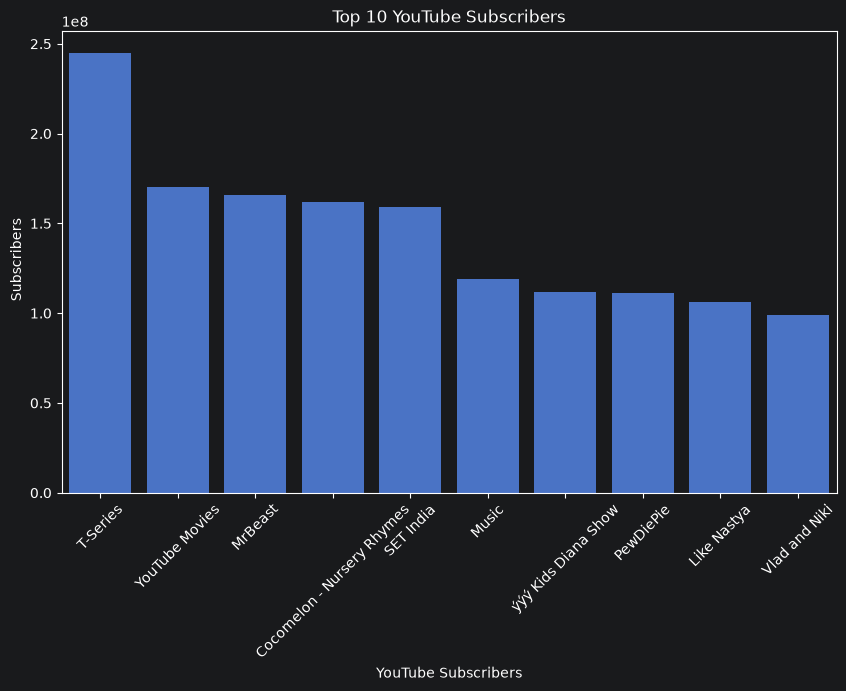

In [14]:
#   TOP 10 YOUTUBERS BY SUBSCRIBERS
import matplotlib.pyplot as plt
import seaborn as sns

top10=df.nlargest(10,"subscribers")
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="Youtuber",y="subscribers")

plt.title("Top 10 YouTube Subscribers")
plt.xlabel("YouTube Subscribers")
plt.ylabel(" Subscribers")
plt.xticks(rotation=45)
plt.show()


### Insight:
T-Series is the most subscribed channel with 245 million subscribers.
The top 5 channels have more than 150 million subscribers, indicating a significant concentration of audience among a few creators.

##  Top UK YouTubers by Subscribers

This analysis identifies the most subscribed YouTube channels in the United Kingdom and helps understand the concentration of audience among leading creators.

In [13]:
uk_df=df[df["Country"]=="United Kingdom"]

In [14]:
uk_df.shape

(43, 28)

In [17]:
# 1)top 10 uk youtubers by subscribers
uk_df.nlargest(10,"subscribers")[["Youtuber","subscribers"]]

,Youtuber,subscribers
16,5-Minute Crafts,80100000
39,Ed Sheeran,53500000
127,NoCopyrightSounds,33400000
137,Mr Bean,32100000
150,Peppa Pig - Official Channel,31400000
163,Adele,30200000
197,DanTDM,27400000
232,Coldplay,25300000
242,Dan Rhodes,24800000
262,KSI,24100000


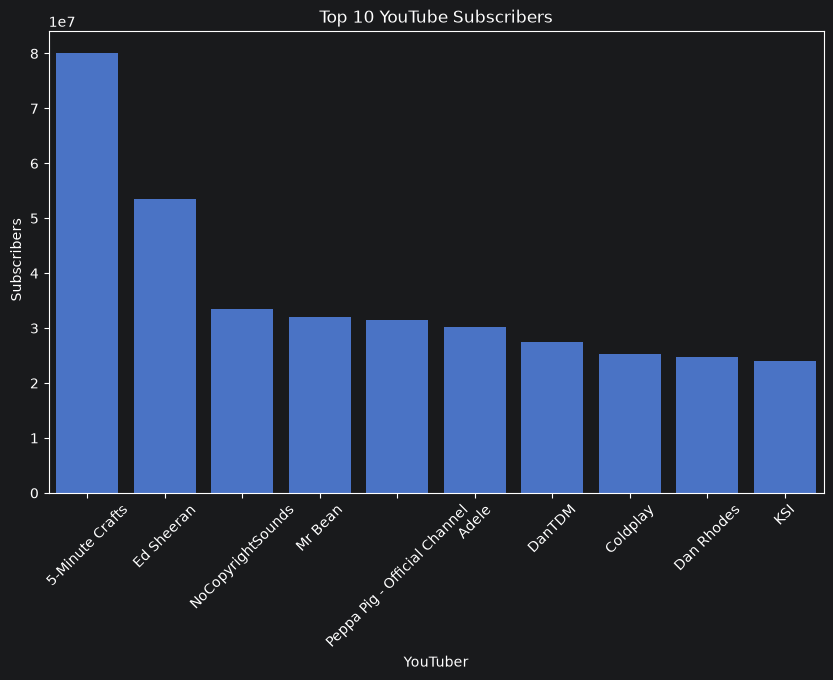

In [18]:
#Visualization
top_uk=uk_df.nlargest(10,"subscribers")
plt.figure(figsize=(10,6))

sns.barplot(data=top_uk,x="Youtuber",y="subscribers")
plt.title("Top 10 YouTube Subscribers")
plt.xlabel("YouTuber")
plt.ylabel(" Subscribers")
plt.xticks(rotation=45)

plt.show()

# Insight

5-Minute Crafts is the most subscribed UK-based YouTube channel in the dataset with over 80 million subscribers, followed by Ed Sheeran with 53.5 million subscribers.

The top UK channels belong to diverse categories including entertainment,music, educational content, and children's content.
Music creators such as Ed Sheeran, Adele, and Coldplay also maintain a strong presence, highlighting the popularity of music-related content among global audiences.

In [19]:
#2) top 3 channels have uploaded the most videos?
top_uploads=uk_df.nlargest(3,"uploads")[["Youtuber","uploads"]]



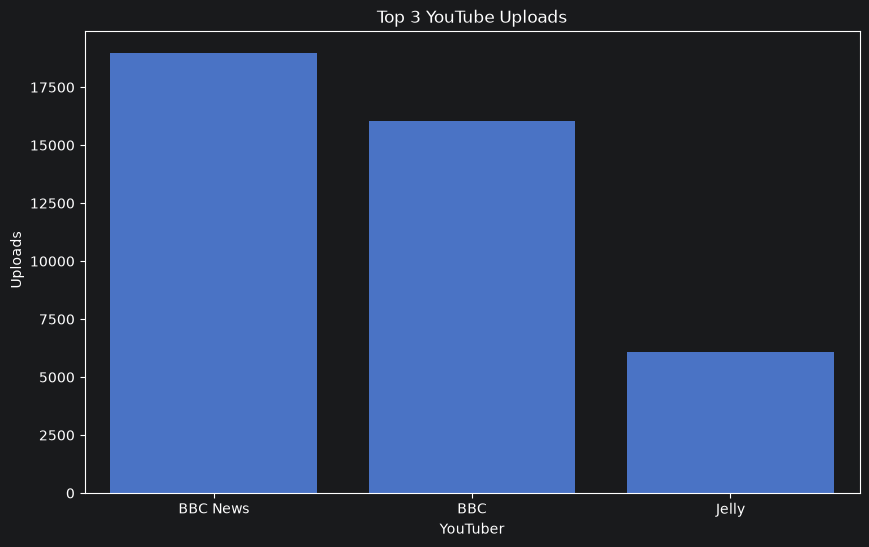

In [20]:
#visulaization
plt.figure(figsize=(10,6))

sns.barplot(data=top_uploads,x="Youtuber",y="uploads")
plt.title("Top 3 YouTube Uploads")
plt.xlabel("YouTuber")
plt.ylabel(" Uploads")

plt.show()

In [24]:
#3) top 3 channels have most views
top_views = uk_df.nlargest(3, "video views")[["Youtuber", "video views"]]
top_views

,Youtuber,video views
39,Ed Sheeran,3.036768e+10
16,5-Minute Crafts,2.623679e+10
150,Peppa Pig - Official Channel,2.291927e+10


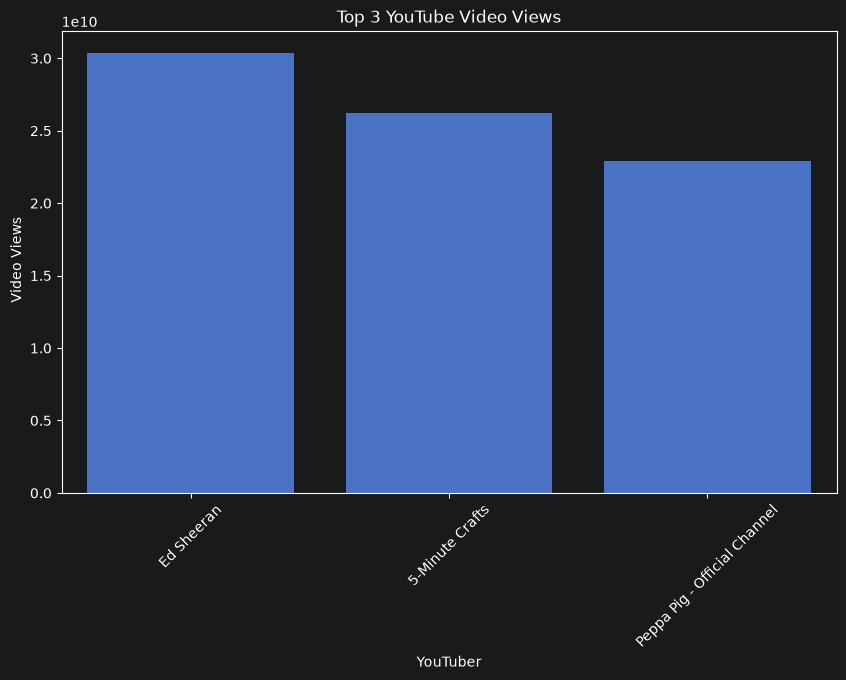

In [25]:
##visulaization
plt.figure(figsize=(10,6))
sns.barplot(data=top_views,x="Youtuber",y="video views")
plt.title("Top 3 YouTube Video Views")
plt.xlabel("YouTuber")
plt.ylabel(" Video Views")
plt.xticks(rotation=45)
plt.show()


# Insight

This analysis identifies the three UK YouTube channels with the highest total views.
Channels with the highest total views have achieved massive audience reach and strong long-term content performance.
These channels may be attractive candidates for marketing collaborations because they can expose products and campaigns to a very large audience.


In [31]:
#4)Top 3 UK YouTubers by Average Views Per Video
uk_df["avg_views_per_video"] = uk_df["video views"] / uk_df["uploads"]

In [28]:
top_avg_views=uk_df.nlargest(3,"avg_views_per_video")[["Youtuber","avg_views_per_video"]]

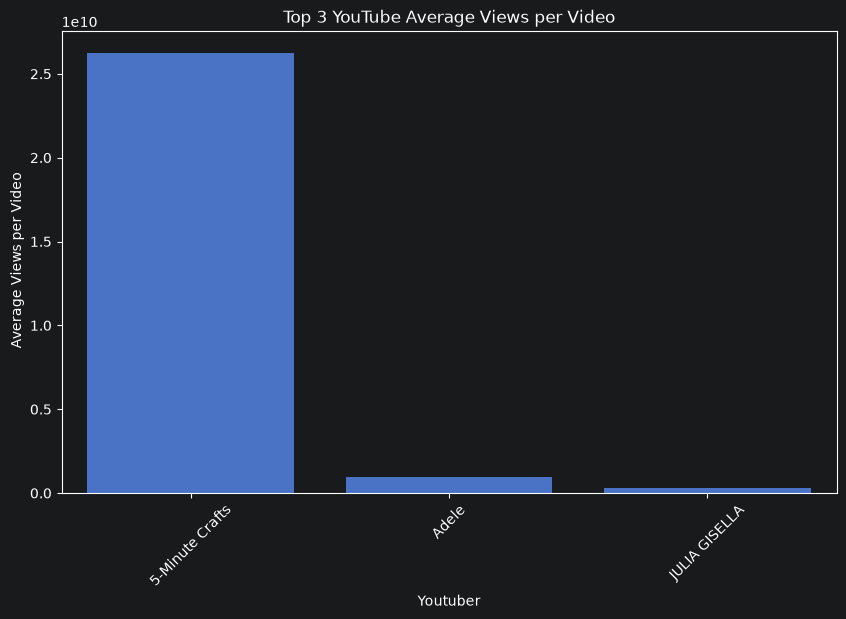

In [29]:
# visulazation
plt.figure(figsize=(10,6))

sns.barplot(data=top_avg_views,x="Youtuber",y="avg_views_per_video")
plt.title("Top 3 YouTube Average Views per Video")
plt.ylabel(" Average Views per Video")
plt.xlabel("Youtuber")
plt.xticks(rotation=45)
plt.show()

## Insight

This analysis identifies the UK YouTube channels that generate the highest average views per uploaded video.
A high average views per video value indicates strong content performance and audience interest.
These creators achieve high visibility without necessarily uploading the largest number of videos, suggesting efficient content strategies and strong viewer engagement.

In [24]:
# 5)top 3 UK youtuber by views per subscriber
uk_df["avg_views_per_subscriber"] = uk_df["video views"] / uk_df["subscribers"]

In [25]:
top_views_subscriber=uk_df.nlargest(3,"avg_views_per_subscriber")[["Youtuber","avg_views_per_subscriber"]]

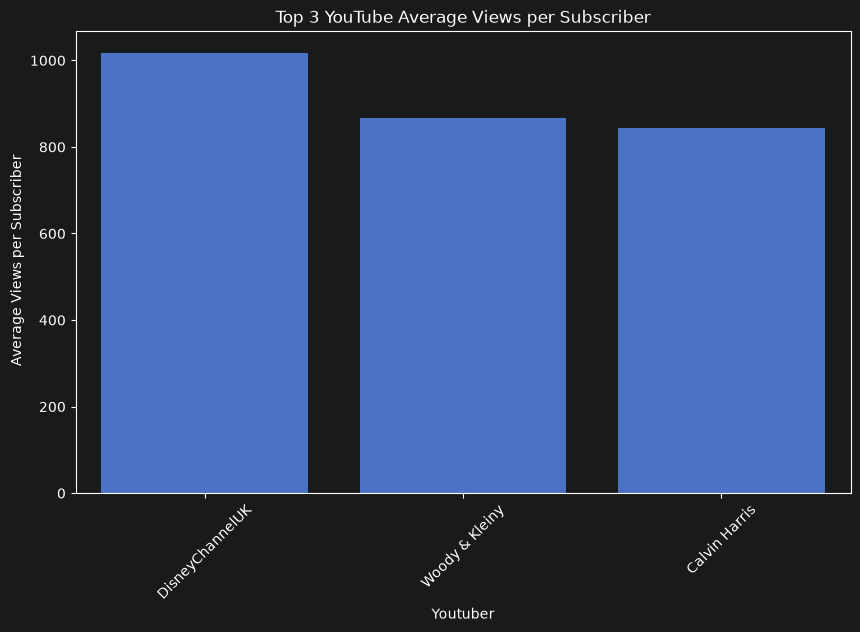

In [26]:
#visualization
plt.figure(figsize=(10,6))
sns.barplot(data=top_views_subscriber,x="Youtuber",y="avg_views_per_subscriber")
plt.title("Top 3 YouTube Average Views per Subscriber")
plt.xlabel("Youtuber")
plt.ylabel(" Average Views per Subscriber")
plt.xticks(rotation=45)

plt.show()

## Insight

  This analysis identifies the UK YouTube channels that generate the highest number of views relative to their subscriber base.
  A high views-per-subscriber ratio suggests that a channel's content reaches audiences beyond its subscribers and attracts strong organic traffic.
  Lower Subscribers + High Views per Subscriber → Content is spreading well and reaching non-subscribers.
  These channels demonstrate excellent content visibility and audience engagement, making them attractive for brand collaborations and marketing campaigns.

In [32]:
# 6)top 3 uk youtubers by subscriber engagement rate
uk_df["engagement_rate"]=uk_df["avg_views_per_video"]/uk_df["subscribers"]

In [33]:
top_engagement=uk_df.nlargest(3,"engagement_rate")[["Youtuber","engagement_rate"]]

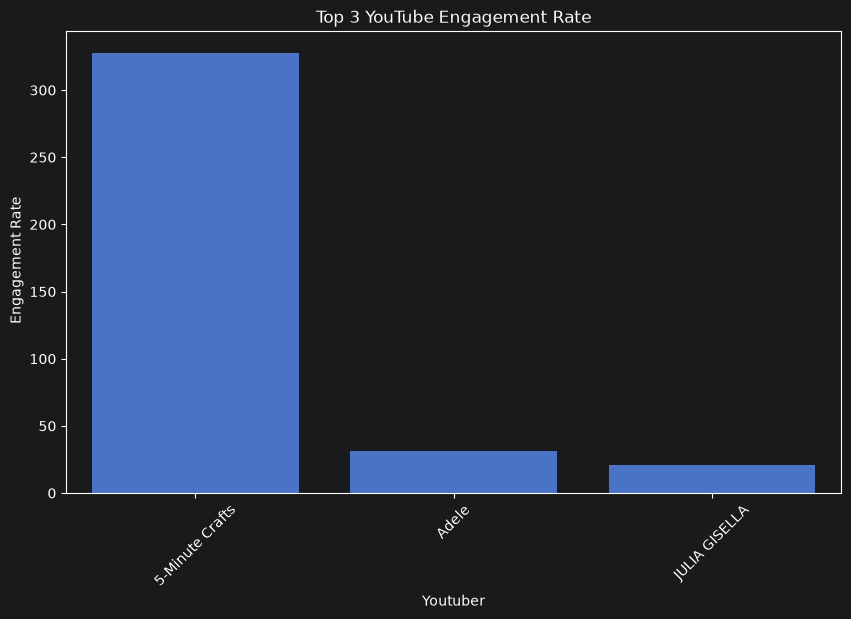

In [34]:
#visualization
plt.figure(figsize=(10,6))
sns.barplot(data=top_engagement,x="Youtuber",y="engagement_rate")
plt.title("Top 3 YouTube Engagement Rate")
plt.xlabel("Youtuber")
plt.ylabel(" Engagement Rate")
plt.xticks(rotation=45)
plt.show()

## Insight

This analysis identifies the UK YouTube channels with the highest engagement relative to their subscriber base.
A high engagement rate indicates that subscribers actively watch and interact with the creator's content.
These channels demonstrate strong audience loyalty and content effectiveness, making them valuable partners for brands seeking meaningful audience engagement rather than just large subscriber counts.

# Key Findings
1. Subscriber concentration — A small number of channels account for a disproportionate share of total subscribers across the dataset.
2. Varied content strategies — Upload frequency differs widely between channels, reflecting distinct approaches to content production and audience retention.
3. Subscribers ≠ engagement — A large subscriber base doesn't reliably predict high engagement; some smaller channels outperform bigger ones.
4. Strong content effectiveness — Several creators post consistently high average views per video, a signal of content that resonates well beyond just their subscriber count.
5. Organic reach beyond the subscriber base — Certain channels draw view counts well above what their subscriber numbers alone would predict, pointing to strong discoverability (via search, recommendations, or shares).
6. Engagement over scale for marketing — For brand and marketing purposes, an actively engaged smaller audience is often more valuable than a large but passive subscriber count.

# Recommendations
1. For maximum reach — Partner with channels that have the highest subscriber counts to maximize raw exposure.
2. For deeper engagement — Prioritize creators with strong engagement rates, since active audiences are more likely to act on a campaign than passive ones.
3. For ROI-conscious campaigns — Favor channels with high average views per video over those with large but less active subscriber bases; view performance often translates more directly to marketing return.
4. For overall creator vetting — Evaluate partnerships using a combined view of subscribers, views, and engagement rather than any single metric in isolation.
5. For audience growth — Work with creators who show strong organic reach, since they're more likely to introduce a brand to new audiences beyond their existing subscriber base.

# SQL Business Analysis

In [35]:
import sqlite3

conn = sqlite3.connect("youtube.db")
uk_df.to_sql("youtube", conn, if_exists="replace", index=False)

43

In [37]:
query="""
select * from youtube
limit 5
"""
result = pd.read_sql(query, conn)
result


,rank,Youtuber,subscribers,video views,category,Title,uploads,Country,Abbreviation,channel_type,...,created_date,Gross tertiary education enrollment (%),Population,Unemployment rate,Urban_population,Latitude,Longitude,avg_views_per_subscriber,avg_views_per_video,engagement_rate
0,17,5-Minute Crafts,80100000,2.623679e+10,Howto & Style,5-Minute Crafts 2.0,1,United Kingdom,GB,Entertainment,...,27.0,60.0,66834405.0,3.85,55908316.0,55.378051,-3.435973,327.550440,2.623679e+10,327.550440
1,40,Ed Sheeran,53500000,3.036768e+10,Music,Ed Sheeran,383,United Kingdom,GB,Music,...,8.0,60.0,66834405.0,3.85,55908316.0,55.378051,-3.435973,567.620126,7.928897e+07,1.482037
2,128,NoCopyrightSounds,33400000,1.053073e+10,Music,NoCopyrightSounds,1331,United Kingdom,GB,Music,...,14.0,60.0,66834405.0,3.85,55908316.0,55.378051,-3.435973,315.291290,7.911893e+06,0.236883
3,138,Mr Bean,32100000,1.060224e+10,Shows,Mr Bean,3091,United Kingdom,GB,Comedy,...,4.0,60.0,66834405.0,3.85,55908316.0,55.378051,-3.435973,330.287729,3.430034e+06,0.106855
4,151,Peppa Pig - Official Channel,31400000,2.291927e+10,Film & Animation,Peppa Pig - Official Channel,3589,United Kingdom,GB,Education,...,9.0,60.0,66834405.0,3.85,55908316.0,55.378051,-3.435973,729.913112,6.385977e+06,0.203375


In [55]:
# 1)top to youtubers by subscribers
query= """
select youtuber,subscribers
 from youtube
order by subscribers  desc
limit 10
"""
result=pd.read_sql(query,conn)
result






,Youtuber,subscribers
0,5-Minute Crafts,80100000
1,Ed Sheeran,53500000
2,NoCopyrightSounds,33400000
3,Mr Bean,32100000
4,Peppa Pig - Official Channel,31400000
5,Adele,30200000
6,DanTDM,27400000
7,Coldplay,25300000
8,Dan Rhodes,24800000
9,KSI,24100000


In [57]:
# 2)top 10 youtubers by total views
query="""
select youtuber,"video views"
from youtube
order by "video views" desc
limit 10
"""
result=pd.read_sql(query,conn)
result

,Youtuber,video views
0,Ed Sheeran,3.036768e+10
1,5-Minute Crafts,2.623679e+10
2,Peppa Pig - Official Channel,2.291927e+10
3,DanTDM,1.941789e+10
4,Dan Rhodes,1.738758e+10
5,Coldplay,1.733166e+10
6,Calvin Harris,1.601404e+10
7,Mister Max,1.551015e+10
8,Jelly,1.477703e+10
9,Miss Katy,1.469699e+10


In [59]:
# 3)top 10 uk youtubers by uploads
query="""
select youtuber,uploads
from youtube
order by uploads desc
limit 10
"""
result=pd.read_sql(query,conn)
result

,Youtuber,uploads
0,BBC News,18972
1,BBC,16047
2,Jelly,6066
3,DisneyChannelUK,4422
4,Britain's Got Talent,4225
5,DanTDM,3664
6,Peppa Pig - Official Channel,3589
7,Mr Bean,3091
8,Panda,2452
9,MoreAliA,2324


In [61]:
# 4)avg subscribers
query="""
select avg(subscribers) as avg_subscribers
from youtube
"""
result=pd.read_sql(query,conn)
result


,avg_subscribers
0,2.133488e+07


In [62]:
# 5)avg video views
query="""
select avg("video views") as avg_views
from youtube
"""
result=pd.read_sql(query,conn)
result

,avg_views
0,1.001318e+10


In [64]:
# 6)no channels per category
query="""
select category, count(*) as total_channels
from youtube
group by category
order by total_channels desc
"""
result=pd.read_sql(query,conn)
result

,category,total_channels
0,Music,14
1,Entertainment,10
2,Gaming,7
3,People & Blogs,2
4,Film & Animation,2
5,Sports,1
6,Shows,1
7,Science & Technology,1
8,Pets & Animals,1
9,News & Politics,1


In [65]:
# 7)top categories by avg subcribers
query="""
select category,
       round(avg(subscribers),0) AS avg_subscribers
from youtube
group by category
order by  avg_subscribers DESC
"""
result=pd.read_sql(query,conn)
result


,category,avg_subscribers
0,Howto & Style,80100000.0
1,Shows,32100000.0
2,Film & Animation,27500000.0
3,People & Blogs,23600000.0
4,Music,22014286.0
5,Entertainment,18620000.0
6,Gaming,17885714.0
7,Science & Technology,15400000.0
8,News & Politics,14500000.0
9,Sports,14100000.0


In [67]:
#8)top 5 categories by total subscribers
query="""
select category,sum(subscribers) as total_subscribers
from youtube
group by category
order by total_subscribers desc
limit 5
"""
result=pd.read_sql(query,conn)
result

,category,total_subscribers
0,Music,308200000
1,Entertainment,186200000
2,Gaming,125200000
3,Howto & Style,80100000
4,Film & Animation,55000000


In [72]:
#9)top 5 chaneels by views per subscriber
query="""
select youtuber,round(("video views"*1.0)/subscribers,2) as views_per_subscriber
from youtube
order by views_per_subscriber desc
limit 5
"""
result=pd.read_sql(query,conn)
result

,Youtuber,views_per_subscriber
0,DisneyChannelUK,1016.73
1,Woody & Kleiny,867.94
2,Calvin Harris,842.84
3,AdeleVEVO,822.11
4,Peppa Pig - Official Channel,729.91


In [74]:
# 10)top 5 youtubers by views per upload
query="""
select youtuber,round(("video views"*1.0)/uploads,2) as views_per_uploads
from youtube
order by views_per_uploads desc
limit 5
"""
result=pd.read_sql(query,conn)
result

,Youtuber,views_per_uploads
0,5-Minute Crafts,2.623679e+10
1,Adele,9.466072e+08
2,JULIA GISELLA,2.831649e+08
3,AdeleVEVO,2.387283e+08
4,Calvin Harris,2.027094e+08


SQL Analysis Summary
Key SQL Findings
1. Subscribers don't guarantee engagement — The channels with the largest subscriber bases aren't consistently the ones with the strongest engagement rates.
2. Standout retention performers — A handful of channels post exceptional views-per-subscriber ratios, pointing to unusually strong audience retention and content quality.
3. Category dominance — Music and Entertainment lead the UK YouTube ecosystem by both total subscribers and total views.
4. Wide variance in video performance — Average views per video differ substantially across channels, suggesting content quality and audience loyalty drive performance as much as channel size.
5. Success is multidimensional — Subscriber count alone is an incomplete success metric; views, upload frequency, and engagement rate together give a fuller picture.

In [75]:
uk_df.to_csv("uk_youtubers_cleaned.csv", index=False)

In [15]:
uk_df["subscribers"].sum()

np.int64(917400000)